# Tavole e report CSV – Reti violenza

Questo notebook genera **tavole descrittive, controlli e grafici** per ciascun file CSV prodotto dal flusso di analisi.

## Cosa contiene
- caricamento automatico dei CSV
- tavola iniziale con dimensioni e colonne
- report dedicato per ogni file
- riepiloghi per regione
- totali delle colonne numeriche
- grafici base per i prospetti regionali
- controlli mirati per `tabella_reti.csv` e `tabella_soggetti.csv`

> Percorso atteso dei file: stessa cartella del notebook, oppure cartella specificata in `BASE_DIR`.


In [51]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path("output/reports/step_3.2")  # cambia se necessario

CSV_FILES = [
    "prospetto_ambito_per_regione.csv",
    "prospetto_attori_tipo10_per_regione.csv",
    "prospetto_firmatari_tipo10_per_regione.csv",
    "prospetto_governance_tipo10_per_regione.csv",
    "prospetto_proponenti_tipo10_per_regione.csv",
    "prospetto_reti_per_regione.csv",
    "prospetto_soggetti_tipo10_per_regione.csv",
    "prospetto_soggetti_tipo30_per_regione.csv",
    "tabella_reti.csv",
    "tabella_soggetti.csv",
]

dfs = {}
missing = []

for name in CSV_FILES:
    path = BASE_DIR / name
    if path.exists():
        dfs[name] = pd.read_csv(path)
    else:
        missing.append(name)

print("File caricati:", len(dfs))
if missing:
    print("File mancanti:")
    for m in missing:
        print(" -", m)


File caricati: 10


In [52]:
overview = []
for name, df in dfs.items():
    overview.append({
        "file": name,
        "righe": len(df),
        "colonne": len(df.columns),
        "colonne_numeriche": len(df.select_dtypes(include="number").columns),
        "ha_regione": "regione" in df.columns
    })

overview_df = pd.DataFrame(overview).sort_values("file").reset_index(drop=True)
overview_df


,file,righe,colonne,colonne_numeriche,ha_regione
0,prospetto_ambito_per_regione.csv,17,9,8,True
1,prospetto_attori_tipo10_per_regione.csv,17,12,11,True
2,prospetto_firmatari_tipo10_per_regione.csv,15,12,11,True
3,prospetto_governance_tipo10_per_regione.csv,15,12,11,True
4,prospetto_proponenti_tipo10_per_regione.csv,15,12,11,True
5,prospetto_reti_per_regione.csv,17,7,6,True
6,prospetto_soggetti_tipo10_per_regione.csv,17,12,11,True
7,prospetto_soggetti_tipo30_per_regione.csv,17,31,30,True
8,tabella_reti.csv,240,16,9,True
9,tabella_soggetti.csv,4502,19,7,True


## Funzioni di supporto

In [53]:
def numeric_columns(df: pd.DataFrame):
    return list(df.select_dtypes(include="number").columns)

def safe_display(df: pd.DataFrame, n: int = 10):
    if df.empty:
        print("DataFrame vuoto")
    else:
        display(df.head(n))

def report_table(df: pd.DataFrame, group_col: str, top_n: int = 20):
    if group_col not in df.columns:
        print(f"Colonna '{group_col}' non presente")
        return
    out = (
        df.groupby(group_col)
        .size()
        .reset_index(name="totale")
        .sort_values(["totale", group_col], ascending=[False, True])
        .head(top_n)
        .reset_index(drop=True)
    )
    display(out)

def show_numeric_totals(df: pd.DataFrame):
    nums = numeric_columns(df)
    if not nums:
        print("Nessuna colonna numerica")
        return
    totals = pd.DataFrame({
        "colonna": nums,
        "totale": [df[c].sum() for c in nums]
    }).sort_values("colonna").reset_index(drop=True)
    display(totals)

def plot_top_numeric_totals(df: pd.DataFrame, title: str, top_n: int = 12):
    nums = numeric_columns(df)
    if not nums:
        print("Nessuna colonna numerica da graficare")
        return
    totals = pd.Series({c: df[c].sum() for c in nums}).sort_values(ascending=False).head(top_n)
    ax = totals.plot(kind="bar", figsize=(10, 4), title=title)
    ax.set_xlabel("")
    ax.set_ylabel("Totale")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_by_region(df: pd.DataFrame, title: str, total_col: str = None):
    if "regione" not in df.columns:
        print("Colonna 'regione' non presente")
        return
    nums = numeric_columns(df)
    if total_col and total_col in df.columns:
        x = df.set_index("regione")[total_col].sort_values(ascending=False)
    elif nums:
        x = df.set_index("regione")[nums].sum(axis=1).sort_values(ascending=False)
    else:
        print("Nessuna colonna numerica disponibile")
        return
    ax = x.plot(kind="bar", figsize=(10, 4), title=title)
    ax.set_xlabel("")
    ax.set_ylabel("Totale")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## prospetto_ambito_per_regione.csv

In [54]:
name = "prospetto_ambito_per_regione.csv"
df = dfs.get(name)

if df is None:
    print("File non disponibile")
else:
    print("Shape:", df.shape)
    print("Colonne:")
    for c in df.columns:
        print(" -", c)
    safe_display(df, 8)


Shape: (17, 9)
Colonne:
 - regione
 - Comunale
 - Ambito intercomunale (Unione comuni etc.)
 - Area metropolitana/provinciale
 - Ambito sociale
 - Ambito sanitario coincidente con articolazioni locali delle Aziende Sanitarie Locali e/o Case della Salute e/o ATS
 - Ambito regionale/Prov. Autonome
 - Ambito distrettuale - legale
 - Altro


,regione,Comunale,Ambito intercomunale (Unione comuni etc.),Area metropolitana/provinciale,Ambito sociale,Ambito sanitario coincidente con articolazioni locali delle Aziende Sanitarie Locali e/o Case della Salute e/o ATS,Ambito regionale/Prov. Autonome,Ambito distrettuale - legale,Altro
0,Abruzzo,0,0,0,1,0,12,0,0
1,Basilicata,0,0,0,0,0,2,0,0
2,Calabria,0,0,0,0,0,13,0,0
3,Emilia-Romagna,0,0,3,0,0,12,0,0
4,Friuli-Venezia Giulia,0,0,0,0,0,2,0,0
5,Lazio,0,0,41,1,0,52,1,0
6,Liguria,0,0,0,0,0,2,1,0
7,Lombardia,0,0,3,0,0,23,0,1


In [55]:
name = "prospetto_ambito_per_regione.csv"
df = dfs.get(name)

if df is not None:
    print("Totali colonne numeriche")
    show_numeric_totals(df)


Totali colonne numeriche


,colonna,totale
0,Altro,1
1,Ambito distrettuale - legale,5
2,Ambito intercomunale (Unione comuni etc.),0
3,Ambito regionale/Prov. Autonome,173
4,Ambito sanitario coincidente con articolazioni...,1
5,Ambito sociale,5
6,Area metropolitana/provinciale,55
7,Comunale,0


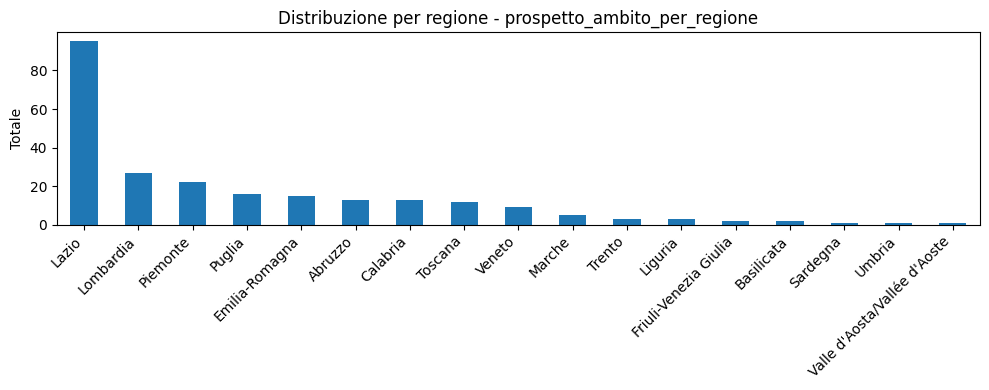

C:\Users\papizzo\AppData\Local\Temp\ipykernel_2844\3857196257.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


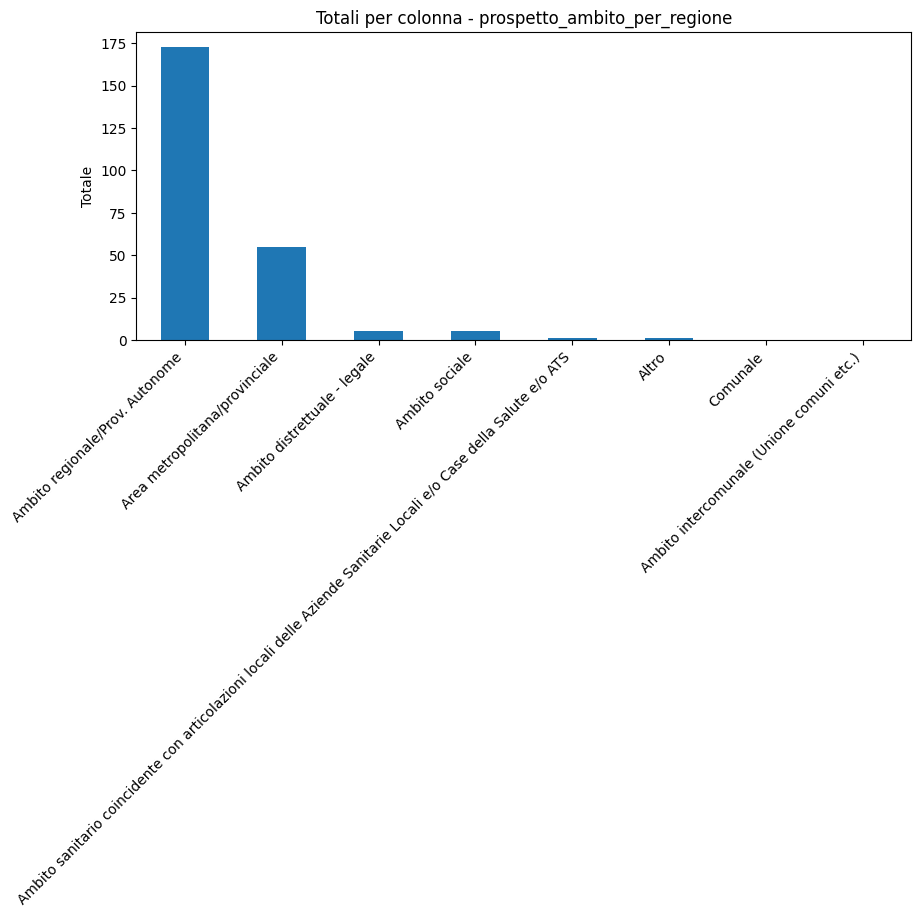

In [56]:
name = "prospetto_ambito_per_regione.csv"
df = dfs.get(name)

if df is not None:
    plot_by_region(df, "Distribuzione per regione - prospetto_ambito_per_regione", total_col=None)
    plot_top_numeric_totals(df, "Totali per colonna - prospetto_ambito_per_regione")


## prospetto_attori_tipo10_per_regione.csv

In [57]:
name = "prospetto_attori_tipo10_per_regione.csv"
df = dfs.get(name)

if df is None:
    print("File non disponibile")
else:
    print("Shape:", df.shape)
    print("Colonne:")
    for c in df.columns:
        print(" -", c)
    safe_display(df, 8)


Shape: (17, 12)
Colonne:
 - regione
 - CAV
 - Settore giudiziario
 - Servizi comunali
 - settore sanitario
 - Regioni/province Autonome
 - Territorio
 - Settore Educativo
 - associazionismo
 - altro
 - Province/Città metropolitane
 - NON CLASSIFICATO


,regione,CAV,Settore giudiziario,Servizi comunali,settore sanitario,Regioni/province Autonome,Territorio,Settore Educativo,associazionismo,altro,Province/Città metropolitane,NON CLASSIFICATO
0,Abruzzo,20,31,50,28,1,8,19,33,22,5,0
1,Basilicata,3,0,2,0,1,0,0,1,2,0,0
2,Calabria,21,29,23,11,3,10,5,7,19,7,0
3,Emilia-Romagna,43,46,135,38,2,11,18,58,46,22,0
4,Friuli-Venezia Giulia,6,18,12,5,0,0,4,6,2,2,0
5,Lazio,69,31,28,21,2,6,28,97,45,2,0
6,Liguria,16,16,9,16,1,5,2,8,7,1,0
7,Lombardia,109,69,257,98,1,96,34,198,89,21,0


In [58]:
name = "prospetto_attori_tipo10_per_regione.csv"
df = dfs.get(name)

if df is not None:
    print("Totali colonne numeriche")
    show_numeric_totals(df)


Totali colonne numeriche


,colonna,totale
0,CAV,442
1,NON CLASSIFICATO,0
2,Province/Città metropolitane,99
3,Regioni/province Autonome,20
4,Servizi comunali,820
5,Settore Educativo,157
6,Settore giudiziario,425
7,Territorio,319
8,altro,355
9,associazionismo,611


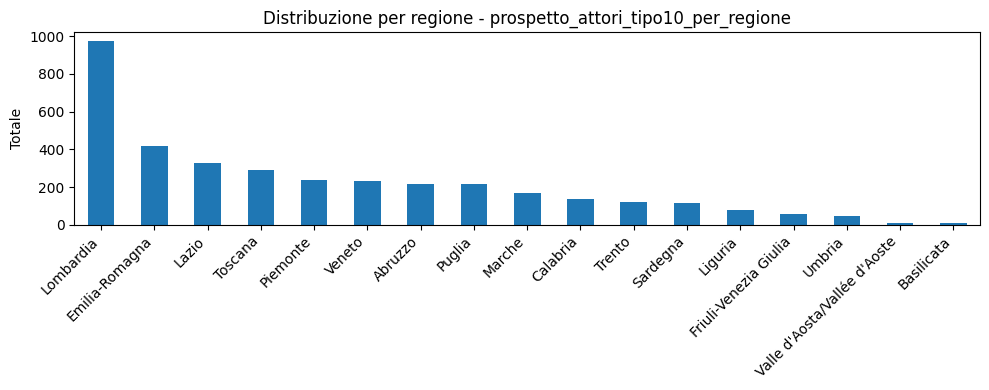

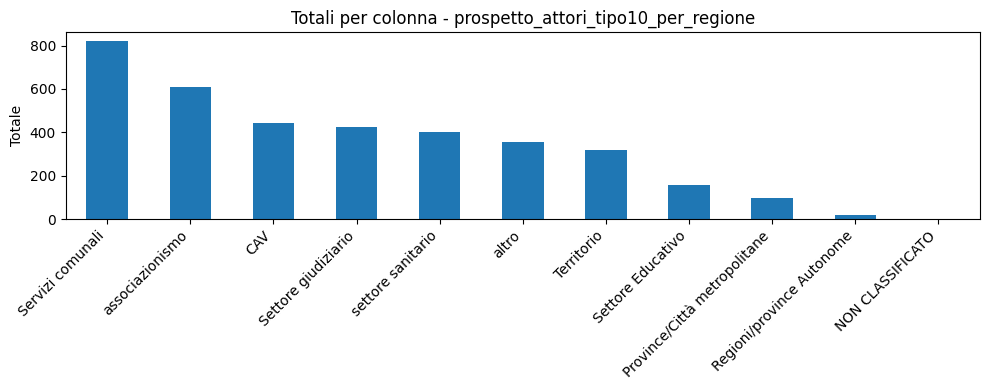

In [59]:
name = "prospetto_attori_tipo10_per_regione.csv"
df = dfs.get(name)

if df is not None:
    plot_by_region(df, "Distribuzione per regione - prospetto_attori_tipo10_per_regione", total_col=None)
    plot_top_numeric_totals(df, "Totali per colonna - prospetto_attori_tipo10_per_regione")


## prospetto_firmatari_tipo10_per_regione.csv

In [60]:
name = "prospetto_firmatari_tipo10_per_regione.csv"
df = dfs.get(name)

if df is None:
    print("File non disponibile")
else:
    print("Shape:", df.shape)
    print("Colonne:")
    for c in df.columns:
        print(" -", c)
    safe_display(df, 8)


Shape: (15, 12)
Colonne:
 - regione
 - CAV
 - Settore giudiziario
 - Servizi comunali
 - settore sanitario
 - Regioni/province Autonome
 - Territorio
 - Settore Educativo
 - associazionismo
 - altro
 - Province/Città metropolitane
 - NON CLASSIFICATO


,regione,CAV,Settore giudiziario,Servizi comunali,settore sanitario,Regioni/province Autonome,Territorio,Settore Educativo,associazionismo,altro,Province/Città metropolitane,NON CLASSIFICATO
0,Abruzzo,16,29,58,21,1,7,18,33,20,3,0
1,Basilicata,0,0,1,0,0,0,0,0,0,0,0
2,Calabria,14,23,6,6,4,8,3,6,17,7,0
3,Emilia-Romagna,24,33,102,23,2,7,13,40,28,15,0
4,Friuli-Venezia Giulia,5,16,32,5,0,0,4,13,6,2,0
5,Lazio,40,22,16,10,2,4,13,83,30,2,0
6,Liguria,4,16,5,2,1,0,2,6,2,1,0
7,Lombardia,80,66,213,82,1,86,27,173,65,21,0


In [61]:
name = "prospetto_firmatari_tipo10_per_regione.csv"
df = dfs.get(name)

if df is not None:
    print("Totali colonne numeriche")
    show_numeric_totals(df)


Totali colonne numeriche


,colonna,totale
0,CAV,264
1,NON CLASSIFICATO,0
2,Province/Città metropolitane,84
3,Regioni/province Autonome,17
4,Servizi comunali,610
5,Settore Educativo,133
6,Settore giudiziario,346
7,Territorio,248
8,altro,228
9,associazionismo,521


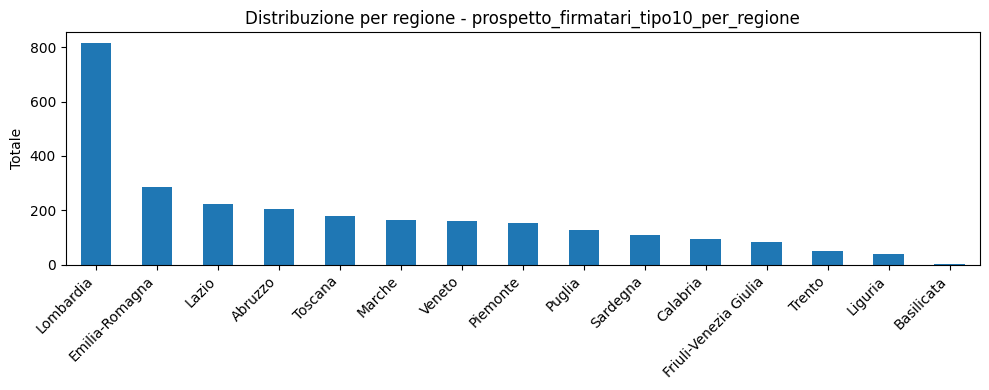

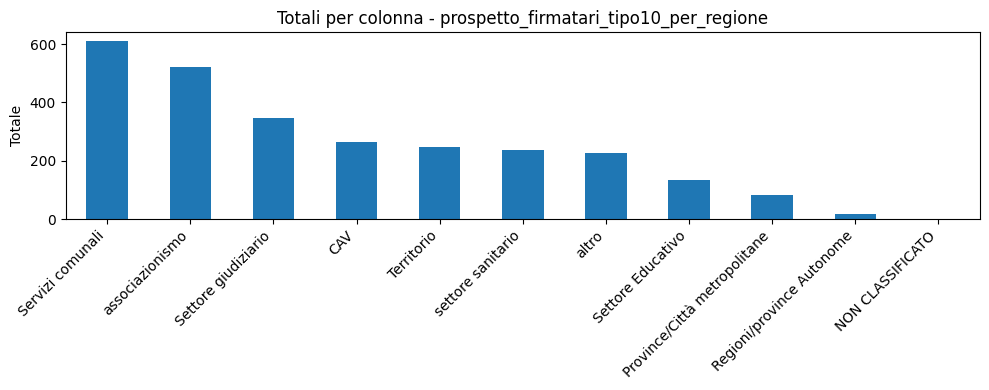

In [62]:
name = "prospetto_firmatari_tipo10_per_regione.csv"
df = dfs.get(name)

if df is not None:
    plot_by_region(df, "Distribuzione per regione - prospetto_firmatari_tipo10_per_regione", total_col=None)
    plot_top_numeric_totals(df, "Totali per colonna - prospetto_firmatari_tipo10_per_regione")


## prospetto_governance_tipo10_per_regione.csv

In [63]:
name = "prospetto_governance_tipo10_per_regione.csv"
df = dfs.get(name)

if df is None:
    print("File non disponibile")
else:
    print("Shape:", df.shape)
    print("Colonne:")
    for c in df.columns:
        print(" -", c)
    safe_display(df, 8)


Shape: (15, 12)
Colonne:
 - regione
 - CAV
 - Settore giudiziario
 - Servizi comunali
 - settore sanitario
 - Regioni/province Autonome
 - Territorio
 - Settore Educativo
 - associazionismo
 - altro
 - Province/Città metropolitane
 - NON CLASSIFICATO


,regione,CAV,Settore giudiziario,Servizi comunali,settore sanitario,Regioni/province Autonome,Territorio,Settore Educativo,associazionismo,altro,Province/Città metropolitane,NON CLASSIFICATO
0,Abruzzo,4,0,5,0,0,0,0,3,2,1,0
1,Calabria,8,1,0,0,0,1,0,1,3,2,0
2,Emilia-Romagna,5,1,5,2,0,0,0,7,6,8,0
3,Friuli-Venezia Giulia,0,1,8,0,0,0,0,0,1,0,0
4,Lazio,8,0,4,3,0,0,0,10,7,0,0
5,Liguria,2,0,4,0,0,0,0,0,2,0,0
6,Lombardia,12,3,30,7,0,4,4,13,7,7,0
7,Marche,1,3,2,0,0,3,0,3,2,0,0


In [64]:
name = "prospetto_governance_tipo10_per_regione.csv"
df = dfs.get(name)

if df is not None:
    print("Totali colonne numeriche")
    show_numeric_totals(df)


Totali colonne numeriche


,colonna,totale
0,CAV,58
1,NON CLASSIFICATO,0
2,Province/Città metropolitane,25
3,Regioni/province Autonome,1
4,Servizi comunali,90
5,Settore Educativo,5
6,Settore giudiziario,10
7,Territorio,29
8,altro,71
9,associazionismo,53


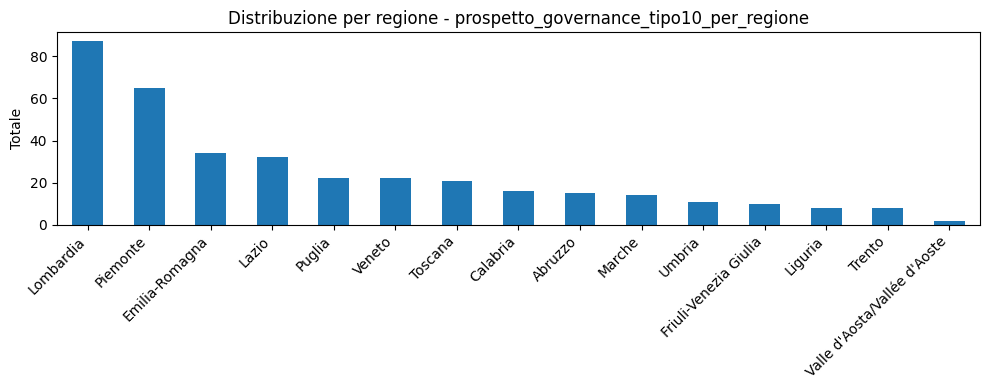

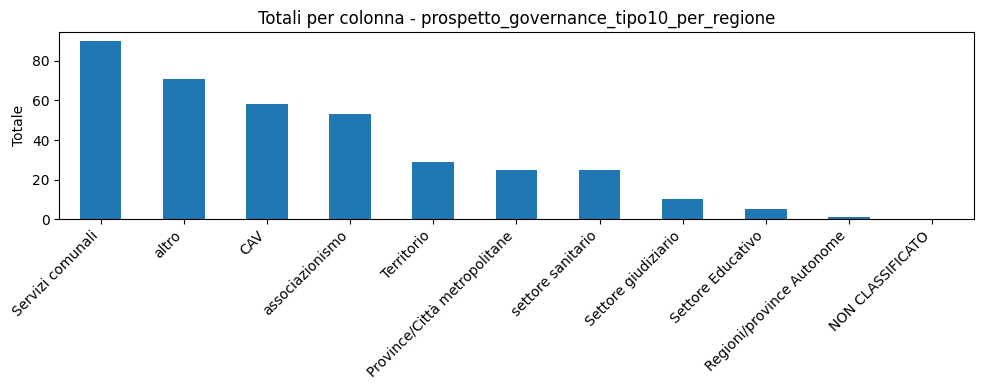

In [65]:
name = "prospetto_governance_tipo10_per_regione.csv"
df = dfs.get(name)

if df is not None:
    plot_by_region(df, "Distribuzione per regione - prospetto_governance_tipo10_per_regione", total_col=None)
    plot_top_numeric_totals(df, "Totali per colonna - prospetto_governance_tipo10_per_regione")


## prospetto_proponenti_tipo10_per_regione.csv

In [66]:
name = "prospetto_proponenti_tipo10_per_regione.csv"
df = dfs.get(name)

if df is None:
    print("File non disponibile")
else:
    print("Shape:", df.shape)
    print("Colonne:")
    for c in df.columns:
        print(" -", c)
    safe_display(df, 8)


Shape: (15, 12)
Colonne:
 - regione
 - CAV
 - Settore giudiziario
 - Servizi comunali
 - settore sanitario
 - Regioni/province Autonome
 - Territorio
 - Settore Educativo
 - associazionismo
 - altro
 - Province/Città metropolitane
 - NON CLASSIFICATO


,regione,CAV,Settore giudiziario,Servizi comunali,settore sanitario,Regioni/province Autonome,Territorio,Settore Educativo,associazionismo,altro,Province/Città metropolitane,NON CLASSIFICATO
0,Abruzzo,9,15,14,11,0,1,3,5,8,0,0
1,Calabria,1,2,2,0,0,0,0,5,1,1,0
2,Emilia-Romagna,4,14,12,9,2,4,4,24,8,4,0
3,Lazio,4,4,3,3,2,0,5,6,3,2,0
4,Liguria,0,0,0,0,1,0,0,0,0,0,0
5,Lombardia,17,44,51,30,1,36,11,43,26,11,0
6,Marche,0,2,3,0,0,1,0,0,0,0,0
7,Piemonte,7,6,6,4,0,5,2,4,5,3,0


In [67]:
name = "prospetto_proponenti_tipo10_per_regione.csv"
df = dfs.get(name)

if df is not None:
    print("Totali colonne numeriche")
    show_numeric_totals(df)


Totali colonne numeriche


,colonna,totale
0,CAV,45
1,NON CLASSIFICATO,0
2,Province/Città metropolitane,24
3,Regioni/province Autonome,10
4,Servizi comunali,109
5,Settore Educativo,28
6,Settore giudiziario,100
7,Territorio,62
8,altro,52
9,associazionismo,91


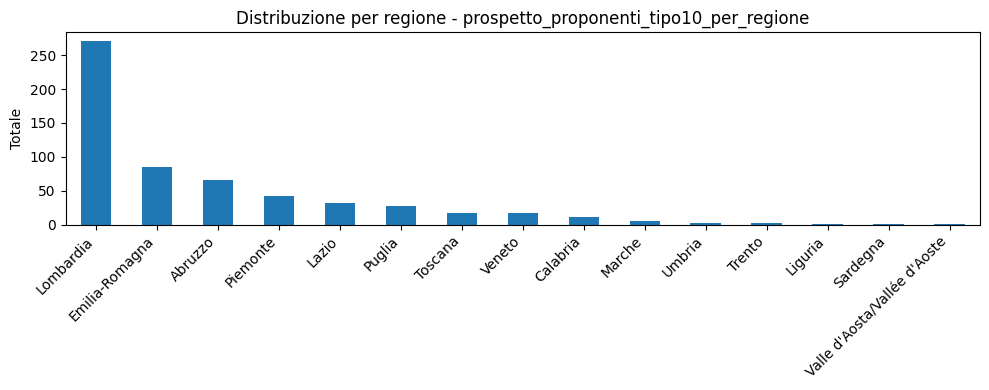

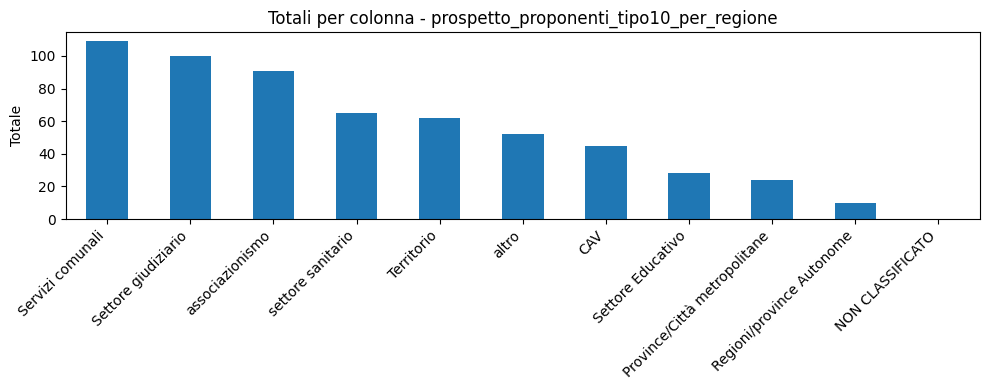

In [68]:
name = "prospetto_proponenti_tipo10_per_regione.csv"
df = dfs.get(name)

if df is not None:
    plot_by_region(df, "Distribuzione per regione - prospetto_proponenti_tipo10_per_regione", total_col=None)
    plot_top_numeric_totals(df, "Totali per colonna - prospetto_proponenti_tipo10_per_regione")


## prospetto_reti_per_regione.csv

In [69]:
name = "prospetto_reti_per_regione.csv"
df = dfs.get(name)

if df is None:
    print("File non disponibile")
else:
    print("Shape:", df.shape)
    print("Colonne:")
    for c in df.columns:
        print(" -", c)
    safe_display(df, 8)


Shape: (17, 7)
Colonne:
 - regione
 - reti
 - soggetti
 - attori
 - firmatari
 - proponenti
 - governance


,regione,reti,soggetti,attori,firmatari,proponenti,governance
0,Abruzzo,13,258,216,206,65,15
1,Basilicata,2,9,9,0,0,0
2,Calabria,13,185,136,96,13,16
3,Emilia-Romagna,15,478,419,287,85,34
4,Friuli-Venezia Giulia,2,87,43,76,0,14
5,Lazio,95,577,330,222,32,32
6,Liguria,3,96,82,40,1,8
7,Lombardia,27,1049,972,814,270,87


In [70]:
name = "prospetto_reti_per_regione.csv"
df = dfs.get(name)

if df is not None:
    print("Totali colonne numeriche")
    show_numeric_totals(df)


Totali colonne numeriche


,colonna,totale
0,attori,3648
1,firmatari,2689
2,governance,367
3,proponenti,586
4,reti,240
5,soggetti,4502


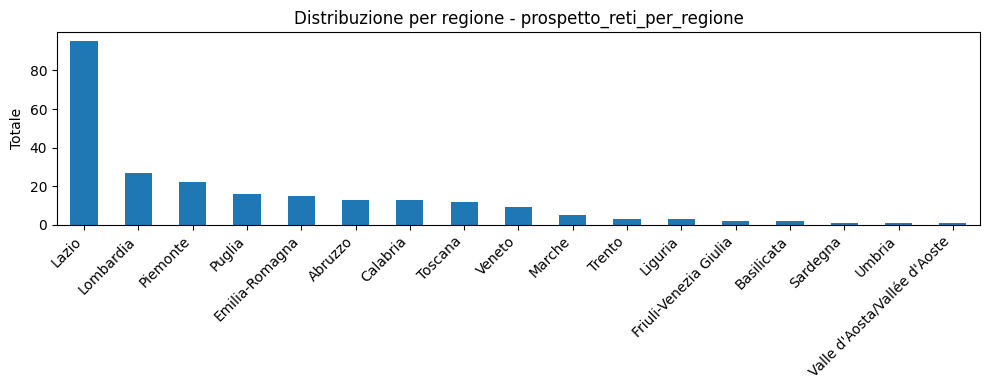

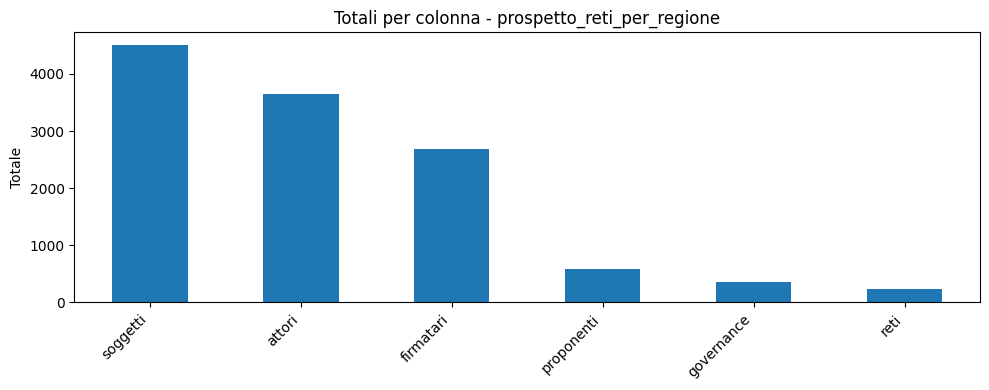

In [71]:
name = "prospetto_reti_per_regione.csv"
df = dfs.get(name)

if df is not None:
    plot_by_region(df, "Distribuzione per regione - prospetto_reti_per_regione", total_col='reti')
    plot_top_numeric_totals(df, "Totali per colonna - prospetto_reti_per_regione")


## prospetto_soggetti_tipo10_per_regione.csv

In [72]:
name = "prospetto_soggetti_tipo10_per_regione.csv"
df = dfs.get(name)

if df is None:
    print("File non disponibile")
else:
    print("Shape:", df.shape)
    print("Colonne:")
    for c in df.columns:
        print(" -", c)
    safe_display(df, 8)


Shape: (17, 12)
Colonne:
 - regione
 - CAV
 - Settore giudiziario
 - Servizi comunali
 - settore sanitario
 - Regioni/province Autonome
 - Territorio
 - Settore Educativo
 - associazionismo
 - altro
 - Province/Città metropolitane
 - NON CLASSIFICATO


,regione,CAV,Settore giudiziario,Servizi comunali,settore sanitario,Regioni/province Autonome,Territorio,Settore Educativo,associazionismo,altro,Province/Città metropolitane,NON CLASSIFICATO
0,Abruzzo,23,35,64,31,2,14,19,34,33,5,0
1,Basilicata,3,0,3,0,1,0,0,1,2,0,0
2,Calabria,33,32,30,16,7,11,10,10,26,8,0
3,Emilia-Romagna,46,51,136,43,10,20,19,60,71,22,0
4,Friuli-Venezia Giulia,6,18,32,5,0,0,4,15,6,2,0
5,Lazio,98,41,56,36,6,16,43,120,150,9,0
6,Liguria,16,21,9,17,1,6,2,9,14,1,0
7,Lombardia,118,70,291,102,1,97,37,203,110,21,0


In [73]:
name = "prospetto_soggetti_tipo10_per_regione.csv"
df = dfs.get(name)

if df is not None:
    print("Totali colonne numeriche")
    show_numeric_totals(df)


Totali colonne numeriche


,colonna,totale
0,CAV,527
1,NON CLASSIFICATO,0
2,Province/Città metropolitane,110
3,Regioni/province Autonome,51
4,Servizi comunali,960
5,Settore Educativo,226
6,Settore giudiziario,479
7,Territorio,367
8,altro,635
9,associazionismo,693


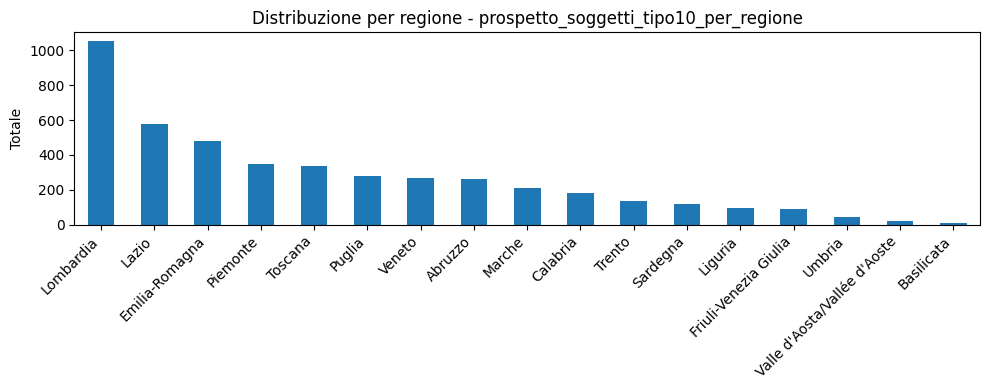

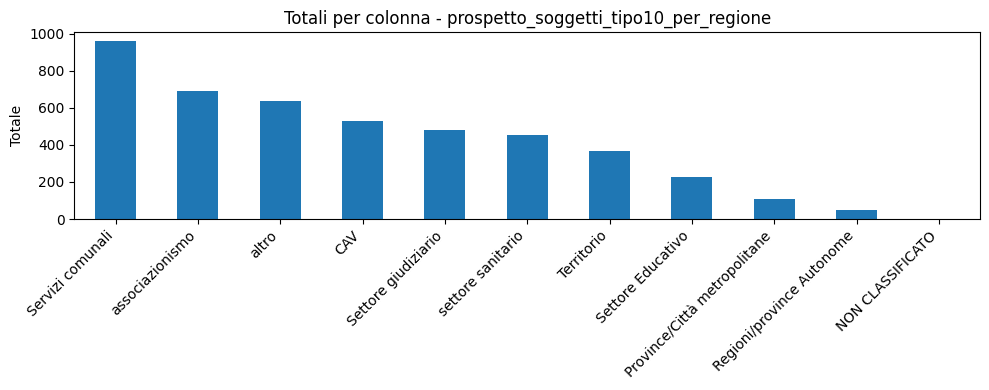

In [74]:
name = "prospetto_soggetti_tipo10_per_regione.csv"
df = dfs.get(name)

if df is not None:
    plot_by_region(df, "Distribuzione per regione - prospetto_soggetti_tipo10_per_regione", total_col=None)
    plot_top_numeric_totals(df, "Totali per colonna - prospetto_soggetti_tipo10_per_regione")


## prospetto_soggetti_tipo30_per_regione.csv

In [75]:
name = "prospetto_soggetti_tipo30_per_regione.csv"
df = dfs.get(name)

if df is None:
    print("File non disponibile")
else:
    print("Shape:", df.shape)
    print("Colonne:")
    for c in df.columns:
        print(" -", c)
    safe_display(df, 8)


Shape: (17, 31)
Colonne:
 - regione
 - ASL (consultori familiari e altri servizi territoriali)
 - Altri ordini professionali (infermieri, ostetriche, giornalisti, commercialisti, ecc.)
 - Altro
 - Ambiti della programmazione sociale e socio-sanitaria (Ambiti Sociali, Piani di Zona, Distretti socio-sanitari, Società della Salute)
 - Associazioni che si occupano di programmi di prevenzione, recupero e trattamento per uomini maltrattanti
 - CAV
 - Carabinieri/Polizia/altre forze dell'ordine
 - Case Rifugio
 - Comuni
 - Ente terzo settore - ETS (iscritto al RUNTS) costituito da donne per le donne
 - Ente terzo settore - ETS (iscritto al RUNTS)[1]
 - Ordine avvocati
 - Ordine medici e odontoiatri e Ordine farmacisti
 - Ordine psicologi e Ordine assistenti sociali
 - Organismi di parità
 - Ospedale (Pronto soccorso, ecc.)
 - Polizia Municipale
 - Prefettura
 - Procura Minorile/ Tribunale minorile
 - Procura Ordinaria/Tribunale/Corte d'appello
 - Province/Città metropolitane
 - Questura
 - Re

,regione,ASL (consultori familiari e altri servizi territoriali),"Altri ordini professionali (infermieri, ostetriche, giornalisti, commercialisti, ecc.)",Altro,"Ambiti della programmazione sociale e socio-sanitaria (Ambiti Sociali, Piani di Zona, Distretti socio-sanitari, Società della Salute)","Associazioni che si occupano di programmi di prevenzione, recupero e trattamento per uomini maltrattanti",CAV,Carabinieri/Polizia/altre forze dell'ordine,Case Rifugio,Comuni,...,Province/Città metropolitane,Questura,Regioni/province Autonome,Scuole/Ufficio scolastico provinciale e regionale,Servizi per l'impiego,Servizi sociali comunali,Servizio abusi e maltrattamenti comunale,Settore educativo comunale,Sindacati/Associazioni di categoria,Università
0,Abruzzo,22,0,33,9,2,15,10,8,55,...,5,5,2,16,2,7,0,0,1,3
1,Basilicata,0,0,2,0,1,2,0,1,3,...,0,0,1,0,0,0,0,0,0,0
2,Calabria,8,0,26,0,0,30,9,3,20,...,8,2,7,9,0,5,0,1,0,0
3,Emilia-Romagna,34,1,71,4,6,44,19,2,106,...,22,8,10,12,4,21,0,2,33,5
4,Friuli-Venezia Giulia,5,0,6,0,0,5,3,1,31,...,2,3,0,3,0,1,0,0,3,1
5,Lazio,18,0,150,7,0,84,13,14,42,...,9,6,6,25,4,9,0,5,7,13
6,Liguria,10,0,14,6,0,13,2,3,6,...,1,5,1,1,0,3,0,0,0,1
7,Lombardia,76,2,110,72,9,81,18,37,274,...,21,11,1,32,13,10,1,0,30,5


In [76]:
name = "prospetto_soggetti_tipo30_per_regione.csv"
df = dfs.get(name)

if df is not None:
    print("Totali colonne numeriche")
    show_numeric_totals(df)


Totali colonne numeriche


,colonna,totale
0,ASL (consultori familiari e altri servizi terr...,322
1,"Altri ordini professionali (infermieri, ostetr...",21
2,Altro,635
3,Ambiti della programmazione sociale e socio-sa...,245
4,Associazioni che si occupano di programmi di p...,38
5,CAV,418
6,Carabinieri/Polizia/altre forze dell'ordine,125
7,Case Rifugio,109
8,Comuni,803
9,Ente terzo settore - ETS (iscritto al RUNTS) c...,18


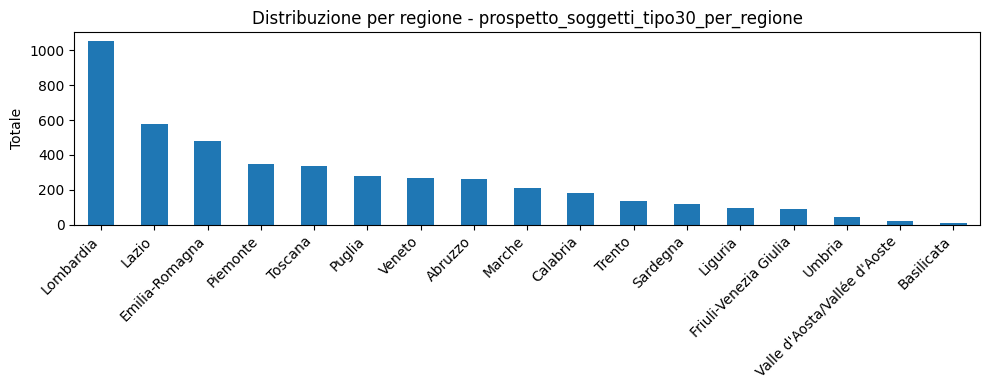

C:\Users\papizzo\AppData\Local\Temp\ipykernel_2844\3857196257.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


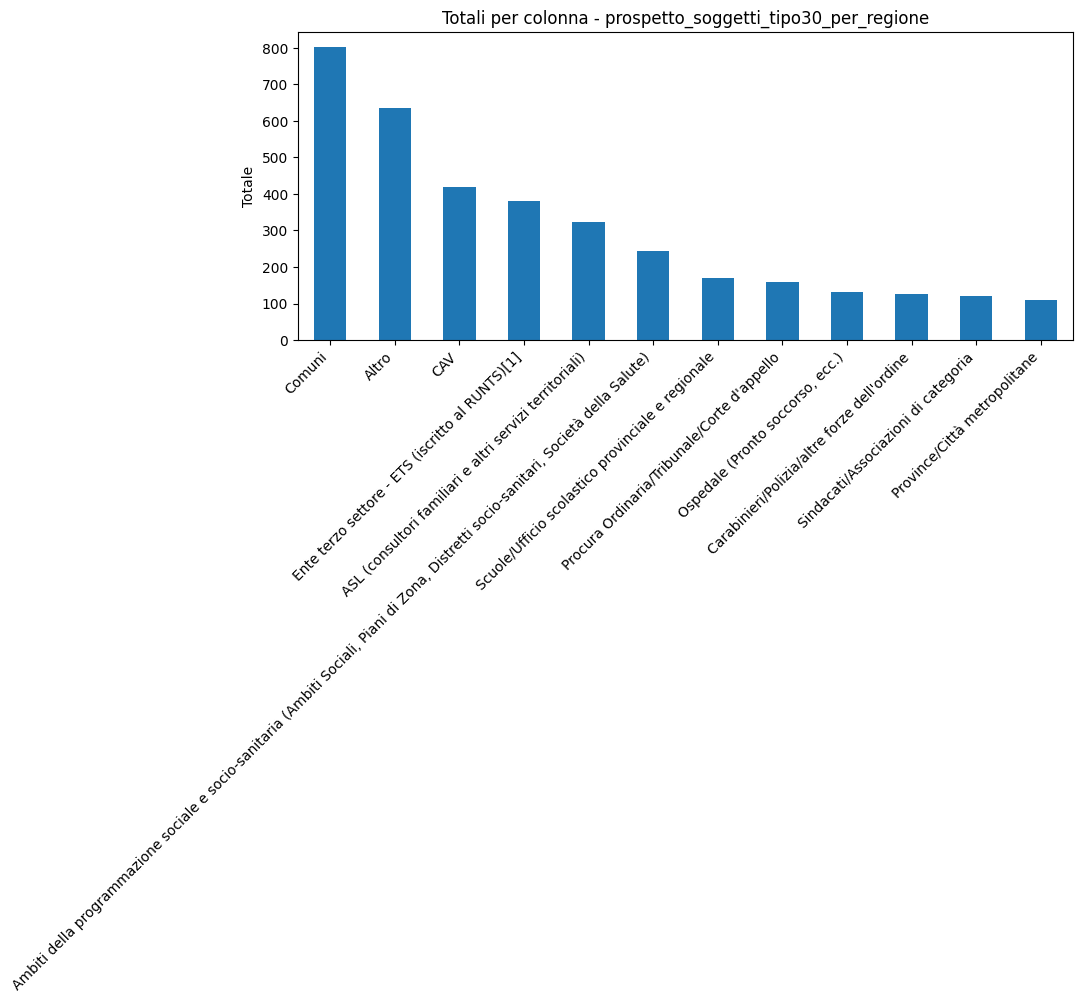

In [77]:
name = "prospetto_soggetti_tipo30_per_regione.csv"
df = dfs.get(name)

if df is not None:
    plot_by_region(df, "Distribuzione per regione - prospetto_soggetti_tipo30_per_regione", total_col=None)
    plot_top_numeric_totals(df, "Totali per colonna - prospetto_soggetti_tipo30_per_regione")


## tabella_reti.csv

In [78]:
name = "tabella_reti.csv"
df = dfs.get(name)

if df is None:
    print("File non disponibile")
else:
    print("Shape:", df.shape)
    print("Colonne:")
    for c in df.columns:
        print(" -", c)
    safe_display(df, 8)


Shape: (240, 16)
Colonne:
 - id_rete
 - file
 - titolo_rete
 - regione
 - provincia
 - ambito_territoriale
 - atto_formale
 - tipologia_dominante_10
 - n_soggetti
 - n_attori
 - n_firmatari
 - n_proponenti
 - n_gestione
 - n_monitoraggio
 - n_coordinamento
 - n_governance


,id_rete,file,titolo_rete,regione,provincia,ambito_territoriale,atto_formale,tipologia_dominante_10,n_soggetti,n_attori,n_firmatari,n_proponenti,n_gestione,n_monitoraggio,n_coordinamento,n_governance
0,13_2406_rta_13_241122101453_4166---Protocollod...,13_2406_rta_13_241122101453_4166---Protocollod...,2406_rta_13_241122101453_4166---ProtocollodiRe...,Abruzzo,NaN,Ambito regionale/Prov. Autonome,0,altro,19,18,15,10,0,0,2,2
1,13_2406_rta_13_241122101856_4166---Protocollod...,13_2406_rta_13_241122101856_4166---Protocollod...,2406_rta_13_241122101856_4166---Protocollodire...,Abruzzo,Chieti,Ambito regionale/Prov. Autonome,0,associazionismo,19,18,13,6,0,0,2,2
2,13_2406_rta_13_241122102615_4166---PROTOCOLLOD...,13_2406_rta_13_241122102615_4166---PROTOCOLLOD...,2406_rta_13_241122102615_4166---PROTOCOLLOD_IN...,Abruzzo,NaN,Ambito regionale/Prov. Autonome,0,Servizi comunali,13,9,6,6,0,0,0,0
3,13_2406_rta_13_241122103653_4166---protocollod...,13_2406_rta_13_241122103653_4166---protocollod...,2406_rta_13_241122103653_4166---protocollodire...,Abruzzo,Teramo,Ambito regionale/Prov. Autonome,0,Servizi comunali,37,37,37,0,0,0,0,0
4,13_2406_rta_13_241122103901_4166---Protocollir...,13_2406_rta_13_241122103901_4166---Protocollir...,2406_rta_13_241122103901_4166---Protocollirete...,Abruzzo,Chieti,Ambito regionale/Prov. Autonome,0,Settore Educativo,54,54,53,11,0,0,2,2
5,13_2406_rta_13_241122104158_4166---Protocollir...,13_2406_rta_13_241122104158_4166---Protocollir...,2406_rta_13_241122104158_4166---Protocollirete...,Abruzzo,NaN,Ambito regionale/Prov. Autonome,0,altro,5,5,5,0,0,0,0,0
6,13_2406_rta_13_241122104428_4166---Protocollor...,13_2406_rta_13_241122104428_4166---Protocollor...,2406_rta_13_241122104428_4166---Protocollorete...,Abruzzo,NaN,Ambito regionale/Prov. Autonome,0,CAV,3,1,0,0,0,0,1,1
7,13_2406_rta_13_241122104842_4166---Protocollod...,13_2406_rta_13_241122104842_4166---Protocollod...,2406_rta_13_241122104842_4166---Protocollodire...,Abruzzo,NaN,Ambito regionale/Prov. Autonome,0,associazionismo,5,4,4,0,0,0,0,0


In [79]:
name = "tabella_reti.csv"
df = dfs.get(name)

if df is not None:
    print("Totali colonne numeriche")
    show_numeric_totals(df)


Totali colonne numeriche


,colonna,totale
0,atto_formale,19
1,n_attori,3648
2,n_coordinamento,195
3,n_firmatari,2689
4,n_gestione,143
5,n_governance,367
6,n_monitoraggio,46
7,n_proponenti,586
8,n_soggetti,4502


In [80]:
df = dfs.get("tabella_reti.csv")
if df is not None:
    print("Reti per regione")
    report_table(df, "regione", top_n=30)

    print("\nAmbito territoriale")
    report_table(df, "ambito_territoriale", top_n=20)

    print("\nTipologia dominante 10")
    report_table(df, "tipologia_dominante_10", top_n=20)


Reti per regione


,regione,totale
0,Lazio,95
1,Lombardia,27
2,Piemonte,22
3,Puglia,16
4,Emilia-Romagna,15
5,Abruzzo,13
6,Calabria,13
7,Toscana,12
8,Veneto,9
9,Marche,5



Ambito territoriale


,ambito_territoriale,totale
0,Ambito regionale/Prov. Autonome,173
1,Area metropolitana/provinciale,55
2,Ambito distrettuale - legale,5
3,Ambito sociale,5
4,Altro,1
5,Ambito sanitario coincidente con articolazioni...,1



Tipologia dominante 10


,tipologia_dominante_10,totale
0,associazionismo,61
1,altro,46
2,Servizi comunali,43
3,CAV,31
4,Territorio,21
5,Settore giudiziario,13
6,Settore Educativo,10
7,settore sanitario,9
8,NON CLASSIFICATO,4
9,Province/Città metropolitane,2


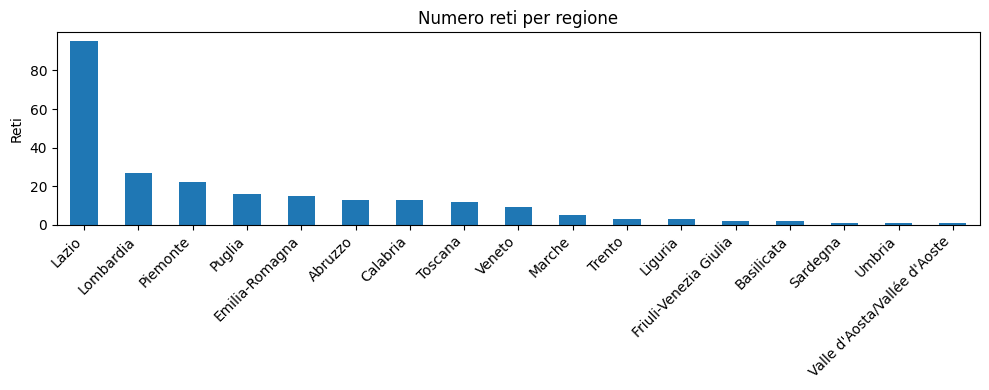

In [81]:
df = dfs.get("tabella_reti.csv")
if df is not None and "regione" in df.columns:
    x = (
        df.groupby("regione")
        .size()
        .sort_values(ascending=False)
    )
    ax = x.plot(kind="bar", figsize=(10, 4), title="Numero reti per regione")
    ax.set_xlabel("")
    ax.set_ylabel("Reti")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## tabella_soggetti.csv

In [82]:
name = "tabella_soggetti.csv"
df = dfs.get(name)

if df is None:
    print("File non disponibile")
else:
    print("Shape:", df.shape)
    print("Colonne:")
    for c in df.columns:
        print(" -", c)
    safe_display(df, 8)


Shape: (4502, 19)
Colonne:
 - id_rete
 - input_json
 - titolo_rete
 - file
 - regione
 - provincia
 - comune_soggetto
 - nome_soggetto
 - tipo_dettaglio
 - tipo_aggregato_10
 - macro_tipologia
 - ruolo_attore
 - ruolo_firmatario
 - ruolo_proponente
 - ruolo_gestione
 - ruolo_monitoraggio
 - ruolo_coordinamento
 - ruolo_governance_totale
 - stato_osservazione


,id_rete,input_json,titolo_rete,file,regione,provincia,comune_soggetto,nome_soggetto,tipo_dettaglio,tipo_aggregato_10,macro_tipologia,ruolo_attore,ruolo_firmatario,ruolo_proponente,ruolo_gestione,ruolo_monitoraggio,ruolo_coordinamento,ruolo_governance_totale,stato_osservazione
0,13_2406_rta_13_241122103901_4166---Protocollir...,all_risultati_enriched_2.4.json,2406_rta_13_241122103901_4166---Protocollirete...,13_2406_rta_13_241122103901_4166---Protocollir...,Abruzzo,Chieti,San Salvo,Associazione Dafne Onlus,Altro,altro,altro,1,1,1,0,0,1,1,valido_localizzato
1,18_2406_rta_18_240926103211_4166---PROTOCOLLOv...,all_risultati_enriched_2.4.json,2406_rta_18_240926103211_4166---PROTOCOLLOviol...,18_2406_rta_18_240926103211_4166---PROTOCOLLOv...,Calabria,Cosenza,Corigliano-Rossano,Associazione Mondiversi Onlus,Altro,altro,altro,0,1,0,0,0,0,0,valido_localizzato
2,16_taranto_protocollo Prefettura ProvinciaTara...,all_risultati_enriched_2.4.json,taranto_protocollo Prefettura ProvinciaTaranto,16_taranto_protocollo Prefettura ProvinciaTara...,Puglia,Taranto,Taranto,Associazione onlus Alzaia,Altro,altro,altro,1,1,0,0,0,0,0,valido_localizzato
3,12_2406_rta_12_241004144338_4166---06-Protocol...,all_risultati_enriched_2.4.json,2406_rta_12_241004144338_4166---06-ProtocolloC...,12_2406_rta_12_241004144338_4166---06-Protocol...,Lazio,Roma,Velletri,Caritas,Altro,altro,altro,0,0,0,0,0,0,0,valido_localizzato
4,18_2406_rta_18_240926102706_4166---protocollom...,all_risultati_enriched_2.4.json,2406_rta_18_240926102706_4166---protocollomond...,18_2406_rta_18_240926102706_4166---protocollom...,Calabria,Catanzaro,Catanzaro,Centro Calabrese di Solidarieta,Altro,altro,altro,1,1,1,1,0,1,1,valido_localizzato
5,12_2406_rta_12_241008151247_4166---3.prot.txt,all_risultati_enriched_2.4.json,2406_rta_12_241008151247_4166---3.prot,12_2406_rta_12_241008151247_4166---3.prot.txt,Lazio,Roma,Roma,Centro Italiano di Solidarieta don Mario Picch...,Altro,altro,altro,1,1,0,0,0,0,0,valido_localizzato
6,12_2406_rta_12_240926115028_4166---ProtICROASL...,all_risultati_enriched_2.4.json,2406_rta_12_240926115028_4166---ProtICROASLazi...,12_2406_rta_12_240926115028_4166---ProtICROASL...,Lazio,Roma,Roma,Consiglio Nazionale,Altro,altro,altro,0,0,0,0,0,0,0,valido_localizzato
7,03_2406_rta_03_240925150245_4166---ProtocolloR...,all_risultati_enriched_2.4.json,2406_rta_03_240925150245_4166---ProtocolloRete...,03_2406_rta_03_240925150245_4166---ProtocolloR...,Lombardia,Brescia,Palazzolo sull'Oglio,Fondazione Giuseppe Antonio Galignani E.T.S,Altro,altro,altro,1,1,0,0,0,0,0,valido_localizzato


In [83]:
name = "tabella_soggetti.csv"
df = dfs.get(name)

if df is not None:
    print("Totali colonne numeriche")
    show_numeric_totals(df)


Totali colonne numeriche


,colonna,totale
0,ruolo_attore,3648
1,ruolo_coordinamento,195
2,ruolo_firmatario,2689
3,ruolo_gestione,143
4,ruolo_governance_totale,367
5,ruolo_monitoraggio,46
6,ruolo_proponente,586


In [84]:
df = dfs.get("tabella_soggetti.csv")
if df is not None:
    print("Soggetti per regione")
    report_table(df, "regione", top_n=30)

    print("\nSoggetti per tipo_aggregato_10")
    report_table(df, "tipo_aggregato_10", top_n=20)

    print("\nSoggetti per tipo_dettaglio")
    report_table(df, "tipo_dettaglio", top_n=30)


Soggetti per regione


,regione,totale
0,Lombardia,1050
1,Lazio,575
2,Emilia-Romagna,478
3,Piemonte,350
4,Toscana,339
5,Puglia,278
6,Veneto,268
7,Abruzzo,260
8,Marche,208
9,Calabria,183



Soggetti per tipo_aggregato_10


,tipo_aggregato_10,totale
0,Servizi comunali,960
1,associazionismo,693
2,altro,635
3,CAV,527
4,Settore giudiziario,479
5,settore sanitario,454
6,Territorio,367
7,Settore Educativo,226
8,Province/Città metropolitane,110
9,Regioni/province Autonome,51



Soggetti per tipo_dettaglio


,tipo_dettaglio,totale
0,Comuni,803
1,Altro,635
2,CAV,418
3,Ente terzo settore - ETS (iscritto al RUNTS)[1],381
4,ASL (consultori familiari e altri servizi terr...,322
5,Ambiti della programmazione sociale e socio-sa...,245
6,Scuole/Ufficio scolastico provinciale e regionale,170
7,Procura Ordinaria/Tribunale/Corte d'appello,158
8,"Ospedale (Pronto soccorso, ecc.)",132
9,Carabinieri/Polizia/altre forze dell'ordine,125


In [85]:
df = dfs.get("tabella_soggetti.csv")
if df is not None:
    role_cols = [c for c in [
        "ruolo_attore",
        "ruolo_firmatario",
        "ruolo_proponente",
        "ruolo_gestione",
        "ruolo_monitoraggio",
        "ruolo_coordinamento",
        "ruolo_governance_totale"
    ] if c in df.columns]

    if role_cols:
        role_summary = pd.DataFrame({
            "ruolo": role_cols,
            "totale": [int(df[c].sum()) for c in role_cols]
        }).sort_values("totale", ascending=False).reset_index(drop=True)
        display(role_summary)


,ruolo,totale
0,ruolo_attore,3648
1,ruolo_firmatario,2689
2,ruolo_proponente,586
3,ruolo_governance_totale,367
4,ruolo_coordinamento,195
5,ruolo_gestione,143
6,ruolo_monitoraggio,46


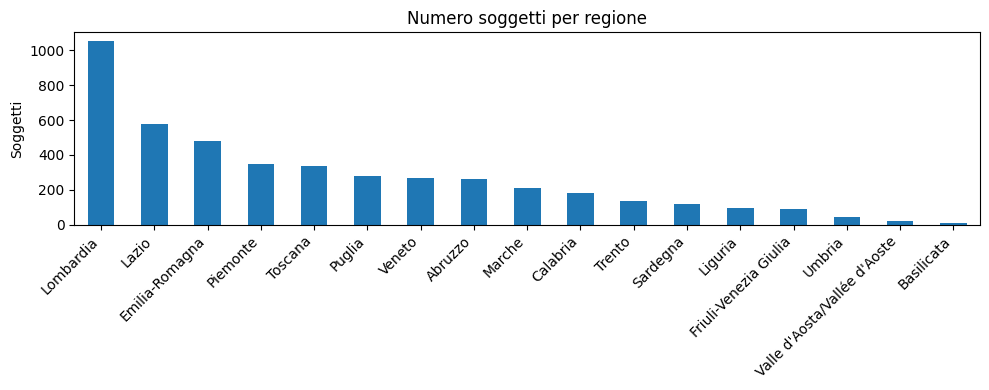

In [86]:
df = dfs.get("tabella_soggetti.csv")
if df is not None and "regione" in df.columns:
    x = (
        df.groupby("regione")
        .size()
        .sort_values(ascending=False)
    )
    ax = x.plot(kind="bar", figsize=(10, 4), title="Numero soggetti per regione")
    ax.set_xlabel("")
    ax.set_ylabel("Soggetti")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
